C:\Users\ELCOT\AppData\Local\Temp\ipykernel_3272\1800082610.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


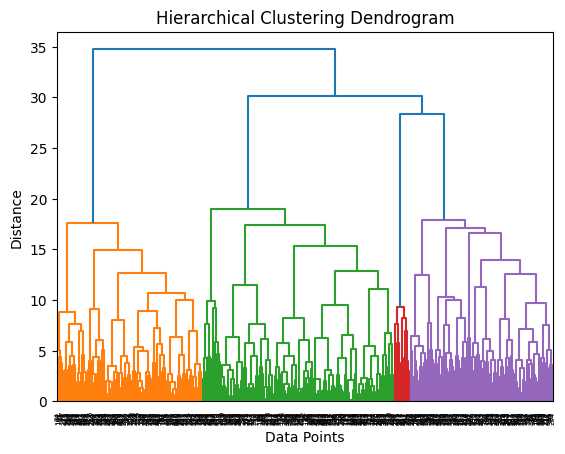

['hierarchical_model.joblib']

In [4]:
# =================================
# PROGRAM 4: HIERARCHICAL CLUSTERING
# =================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("petfinder-mini.csv")

df = df.drop(columns=['Name','PetID','Description'], errors='ignore')
df.fillna(0, inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('AdoptionSpeed', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use small subset for speed
subset = X_scaled[:500]

linked = linkage(subset, method='ward')

plt.figure()
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Save hierarchical clustering linkage and subset data
joblib.dump({"linked": linked, "subset": subset}, "hierarchical_model.joblib")

Cophenetic Correlation: 0.3775
Silhouette Score: 0.1225


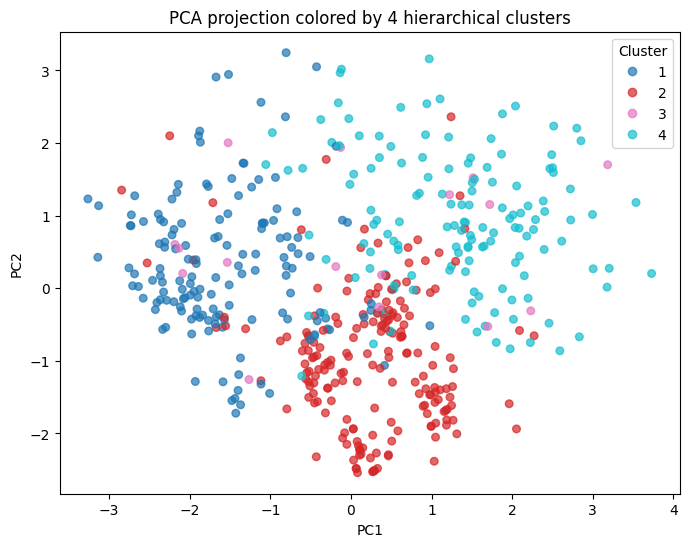

New sample assigned to cluster: 2


In [5]:
# Evaluation: cophenetic correlation coefficient
from scipy.cluster.hierarchy import cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Compute cophenetic correlation (how well the dendrogram preserves pairwise distances)
distances = pdist(subset)
coph_corr, coph_dists = cophenet(linked, distances)
print("Cophenetic Correlation:", round(coph_corr, 4))

# Choose number of clusters and assign labels
n_clusters = 4
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')

# Silhouette score (requires >1 cluster)
sil_score = silhouette_score(subset, cluster_labels)
print("Silhouette Score:", round(sil_score, 4))

# Visualize cluster assignments in 2D via PCA
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(subset)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap='tab10', s=30, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title(f"PCA projection colored by {n_clusters} hierarchical clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Example: predict cluster for a new sample (using nearest cluster centroid in PCA space)
new_sample = X_scaled[500:501]  # take one held-out sample
new_reduced = pca.transform(new_sample)
centroids = np.array([reduced[cluster_labels == k].mean(axis=0) for k in np.unique(cluster_labels)])
assigned = np.argmin(np.linalg.norm(centroids - new_reduced, axis=1)) + 1
print("New sample assigned to cluster:", assigned)
